In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl

In [2]:
arrays = np.load("ensemble_train_results.npz")
arrays

NpzFile 'ensemble_train_results.npz' with keys: step_sizes, linear_solver_regs, grads, natural_grads, fs

In [3]:
arrays['fs'].shape

(500, 60)

In [4]:
natural_grads = arrays['natural_grads'].T

In [5]:
losses_mean = arrays['fs'].T.reshape(5, -1, 500).mean(axis=0)
losses_std = arrays['fs'].T.reshape(5, -1, 500).std(axis=0)

/home/aksenov/miniconda3/envs/neuripp/lib/python3.12/site-packages/numpy/_core/_methods.py:194: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


In [6]:
losses_mean.shape

(12, 500)

In [7]:
step_sizes = arrays['step_sizes'].reshape(-1, 5)[:, 0]

In [8]:
lin_regs = arrays['linear_solver_regs'].reshape(-1, 5)[:, 0]

In [9]:
step_sizes, lin_regs
step_to_cmap = ['Greens', 'Blues', 'Reds', 'Purples']

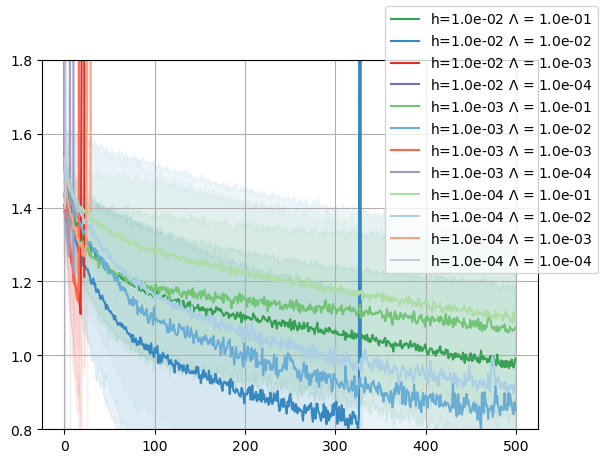

In [10]:
fig, ax = plt.subplots()
for i, (ml, dl, h, reg) in enumerate(zip(losses_mean, losses_std, step_sizes, lin_regs)):
    cmap = mpl.colormaps[step_to_cmap[i % 4]]
    color = cmap((6+np.log10(h)) / 6 )
    ax.plot(ml, label=f"{h=:.1e} $\\Lambda$ = {reg:.1e}", color=color)
    ax.fill_between(range(len(ml)), ml+1.*dl, ml-1*dl, color=color, alpha=0.1)
ax.set_ylim(0.8, 1.8)
# ax.set_yscale('log')
fig.legend(loc='outside upper right')
ax.grid()

In [11]:
losses_mean.min()

np.float32(nan)

In [12]:
step_sizes

array([0.01  , 0.01  , 0.01  , 0.01  , 0.001 , 0.001 , 0.001 , 0.001 ,
       0.0001, 0.0001, 0.0001, 0.0001], dtype=float32)